# CMM544 NLP Assessment

### MediPublish Classification Pipeline
***

## Setup and Imports

In [1]:
# The usual imports and similar to what we used in the labs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
random.seed(123)
np.random.seed(123)

import nltk
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

***
## Section 1: Loading and Understanding the Dataset

In [2]:
# I downloaded these from the github repo linked in the assessment doc

# For Google Colab (active)
from google.colab import drive
drive.mount('/content/drive')

train_file_path = "/content/drive/My Drive/Colab Notebooks/datasets/medical_tc_train.csv"
test_file_path = "/content/drive/My Drive/Colab Notebooks/datasets/medical_tc_test.csv"
labels_file_path = "/content/drive/My Drive/Colab Notebooks/datasets/medical_tc_labels.csv"


# For local execution (uncomment these and comment out the Colab section above)
# train_file_path = "datasets/medical_tc_train.csv"
# test_file_path = "datasets/medical_tc_test.csv"
# labels_file_path = "datasets/medical_tc_labels.csv"

train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)
labels_df = pd.read_csv(labels_file_path)

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
train_df.head()

Mounted at /content/drive
Train: (11550, 2), Test: (2888, 2)


,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."
3,1,Lipolytic factors associated with murine and h...
4,3,Does carotid restenosis predict an increased r...


In [3]:
# Maps the numeric labels to readable names so it's easier to work with
label_map = dict(zip(labels_df['condition_label'], labels_df['condition_name']))
train_df['condition_name'] = train_df['condition_label'].map(label_map)
test_df['condition_name'] = test_df['condition_label'].map(label_map)


# Checking the class balance - the assessment doc mentions 5 departments
print("Training set:")
print(train_df['condition_name'].value_counts())
print("\n")
print("Test set:")
print(test_df['condition_name'].value_counts())

Training set:
condition_name
general pathological conditions    3844
neoplasms                          2530
cardiovascular diseases            2441
nervous system diseases            1540
digestive system diseases          1195
Name: count, dtype: int64


Test set:
condition_name
general pathological conditions    961
neoplasms                          633
cardiovascular diseases            610
nervous system diseases            385
digestive system diseases          299
Name: count, dtype: int64


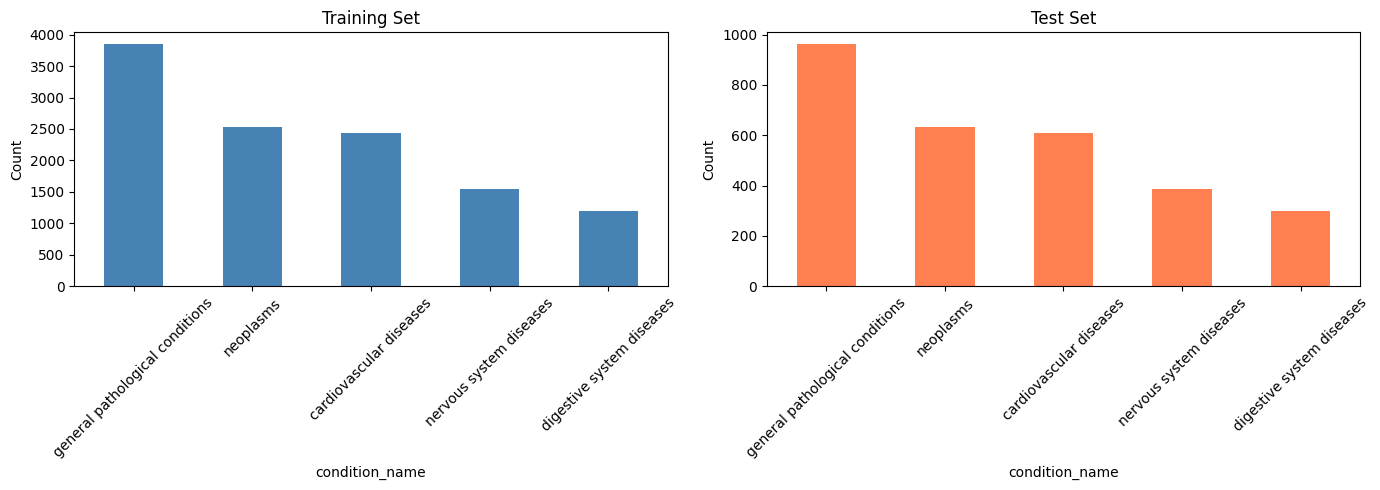

In [4]:
# Visualising the training and test sets as I want to see if theres an imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['condition_name'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Training Set')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

test_df['condition_name'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Test Set')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

There's a clear imbalance. The "general pathological conditions" category has way more samples than digestive system diseases. This will matter when I evaluate later, accuracy alone wont be enough so I'll need to use f1 scores.

In [5]:
# Quick check to see what the actual text looks like
print(train_df.iloc[0]['medical_abstract'][:500])

Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were isolated and maintained in culture for sufficient periods of time so that their biologic activity could be studied as well as the effect of different agents added to the cells in vivo or in vitro. The b


In [6]:
# Checking the average length of abstracts
train_df['word_count'] = train_df['medical_abstract'].apply(lambda x: len(x.split()))
print(train_df['word_count'].describe())

count    11550.000000
mean       179.640606
std         76.369776
min         24.000000
25%        122.000000
50%        175.000000
75%        234.000000
max        596.000000
Name: word_count, dtype: float64


### 1.1 Data Cleaning
During exploration I noticed that the dataset has some issues that needed addressing before I built any models. Specifically, I wanted to check for duplicate abstracts and conflicting labels. If the same abstract is assigned to different condition categories in different rows, this will confuse the classifier. I also needed to check for train/test overlap for any data leakages.

In [7]:
# Checking for duplicates here just in case some abstracts repeat
print(f"Training set size: {len(train_df)}")
print(f"Duplicate abstracts found: {train_df['medical_abstract'].duplicated().sum()}")

# Checking for train/test overlap before any cleaning
raw_overlap = set(train_df['medical_abstract']) & set(test_df['medical_abstract'])
print(f"Train/test overlap (before cleaning): {len(raw_overlap)} abstracts")

Training set size: 11550
Duplicate abstracts found: 2105
Train/test overlap (before cleaning): 988 abstracts


In [8]:
# Data Cleaning (Training Set Only)
# The test set is NOT modified
#
# Three issues identified:
# 1. Train/test overlap: 988 abstracts appear in both sets with
#    DIFFERENT labels (e.g., train=neoplasms, test=general pathological)
# 2. Label 5 acts as umbrella: 82% of multi-label conflicts involve
#    label 5 paired with a specific department (1-4)
# 3. Duplicate rows within training

# Step 1: Remove train/test overlap from training
overlap = set(train_df['medical_abstract']) & set(test_df['medical_abstract'])
print(f"Train/test overlap: {len(overlap)} abstracts")
train_df = train_df[~train_df['medical_abstract'].isin(overlap)].copy()
print(f"After removing overlap: {len(train_df)} rows")

# Step 2: Specific-label priority
# When an abstract has label 5 AND a specific label (1-4), keep the specific one.
# This resolves the umbrella-label ambiguity for training.
def resolve_labels(df):
    resolved = []
    for abstract, group in df.groupby('medical_abstract', sort=False):
        labels = set(group['condition_label'])
        if len(labels) == 1:
            resolved.append(group.iloc[0])
            continue
        specific = labels - {5}
        if len(specific) == 0:
            resolved.append(group.iloc[0])
        elif len(specific) == 1:
            target = list(specific)[0]
            resolved.append(group[group['condition_label'] == target].iloc[0])
        else:
            specific_rows = group[group['condition_label'].isin(specific)]
            resolved.append(specific_rows.iloc[0])
    return pd.DataFrame(resolved).reset_index(drop=True)

train_df = resolve_labels(train_df)
print(f"After label resolution: {len(train_df)} rows")

# Step 3: Drop exact duplicates
train_df = train_df.drop_duplicates(subset='medical_abstract')
print(f"After dedup: {len(train_df)} rows")
print(f"\nTest set: UNMODIFIED ({len(test_df)} rows)")

Train/test overlap: 988 abstracts
After removing overlap: 10453 rows
After label resolution: 8457 rows
After dedup: 8457 rows

Test set: UNMODIFIED (2888 rows)


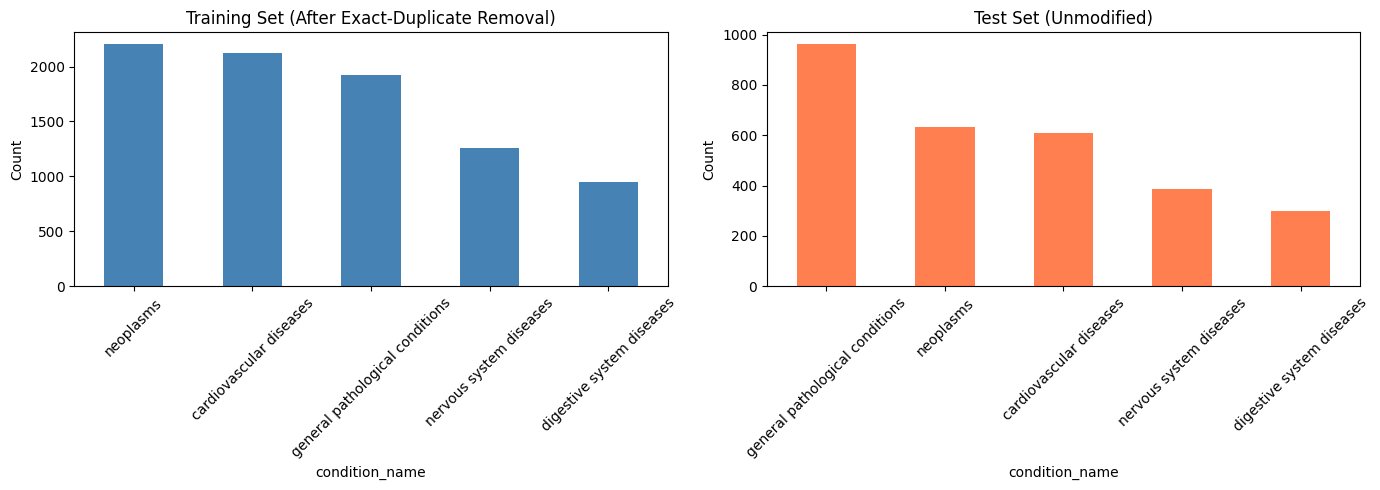

In [9]:
# Visualising the training and test distributions after the revised data handling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['condition_name'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Training Set (After Exact-Duplicate Removal)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

test_df['condition_name'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Test Set (Unmodified)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

***
## Section 2: NLP Pipeline

### 2.1 Pre-processing

I built a custom preprocessor following the pattern from Lab 06. The steps are: lowercasing, punctuation removal, tokenisation with NLTK's word_tokenize, stopword removal (English + domain-specific), and lemmatisation using WordNet. Digits are kept because medical abstracts contain clinically meaningful numbers (dosages, thresholds, patient counts). I chose lemmatisation over stemming because it merges surface variants like "tumor"/"tumors" into canonical forms while preserving exact medical terminology that TF-IDF relies on for matching.

In [10]:
MEDICAL_STOPWORDS = {
    'patient', 'patients', 'case', 'cases', 'study', 'studies',
    'group', 'groups', 'result', 'results',
    'method', 'methods', 'data', 'analysis',
    'report', 'reported', 'reports',
    'conclusion', 'conclusions', 'background', 'objective',
    'objectives', 'purpose', 'finding', 'findings',
    'observed', 'observation',
}


class TextPreprocessor(BaseEstimator, TransformerMixin):
    # Custom preprocessor following Lab 06 pattern.
    def __init__(self):
        self.stop_words = set(stopwords.words('english')) | MEDICAL_STOPWORDS
        self.lemmatizer = WordNetLemmatizer()

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        processed = []
        for text in X:
            text = text.lower()
            text = text.translate(str.maketrans('', '', string.punctuation))
            tokens = word_tokenize(text)
            tokens = [
                self.lemmatizer.lemmatize(t)
                for t in tokens
                if t not in self.stop_words and len(t) > 2
            ]
            processed.append(' '.join(tokens))
        return processed

In [11]:
# Just a quick sanity check - does the preprocessing look right?
preprocessor = TextPreprocessor()
sample = train_df.iloc[0]['medical_abstract']
print("BEFORE:")
print(sample[:300])

print("\n")

result = preprocessor.transform([sample])
print("AFTER:")
print(result[0][:300])

BEFORE:
Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were is


AFTER:
tissue change around loose prosthesis canine model investigate effect antiinflammatory agent aseptically loosened prosthesis provided mean investigating vivo vitro activity cell associated loosening process seven dog cell isolated maintained culture sufficient period time biologic activity could stu


***
### 2.2 Representation Learning - TF-IDF Baseline

I'm starting with TF-IDF since that's what we covered in Lab 05. TF-IDF converts the text into sparse numerical vectors by weighting each term based on how frequently it appears in a document (TF) relative to how common it is across the whole corpus (IDF). This means distinctive medical terms like "carcinoma" or "hepatitis" get high weights because they're frequent in specific condition categories but rare overall.

I configured the TfidfVectorizer with:
- **Bigrams** `ngram_range=(1,2)` this captures two-word medical phrases like "heart failure" or "blood pressure" that unigrams alone would miss.
- **Sublinear TF scaling** `sublinear_tf=True` applies a logarithmic dampening to raw term counts, which prevents very long abstracts from dominating.
- **Vocabulary cap** `max_features=30000` limits the feature space to the most informative terms.

I tested TF-IDF on both preprocessed and raw text to compare which works better.

In [12]:
# Preparing the Data
X_train = train_df['medical_abstract'].tolist()
y_train = train_df['condition_label'].values
X_test = test_df['medical_abstract'].tolist()
y_test = test_df['condition_label'].values

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 8457, Test: 2888


In [13]:
# Applying preprocessing
preprocessor = TextPreprocessor()
print("Preprocessing training set...")
X_train_prep = preprocessor.transform(X_train)
print("Preprocessing test set...")
X_test_prep = preprocessor.transform(X_test)
print("Done.")

Preprocessing training set...
Preprocessing test set...
Done.


In [14]:
# TF-IDF + LinearSVC (raw and preprocessed)
from sklearn.pipeline import Pipeline

pipe_tfidf_svc_raw = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf', LinearSVC(C=0.5, max_iter=5000, class_weight='balanced', random_state=123)),
])
pipe_tfidf_svc_raw.fit(X_train, y_train)
preds_tfidf_svc_raw = pipe_tfidf_svc_raw.predict(X_test)

pipe_tfidf_svc_prep = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf', LinearSVC(C=0.5, max_iter=5000, class_weight='balanced', random_state=123)),
])
pipe_tfidf_svc_prep.fit(X_train_prep, y_train)
preds_tfidf_svc_prep = pipe_tfidf_svc_prep.predict(X_test_prep)

print("TF-IDF + LinearSVC (raw)")
print(f"Accuracy: {accuracy_score(y_test, preds_tfidf_svc_raw):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_tfidf_svc_raw, average='macro'):.4f}")
print(classification_report(y_test, preds_tfidf_svc_raw, target_names=labels_df['condition_name'].tolist()))

print("\nTF-IDF + LinearSVC (preprocessed)")
print(f"Accuracy: {accuracy_score(y_test, preds_tfidf_svc_prep):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_tfidf_svc_prep, average='macro'):.4f}")
print(classification_report(y_test, preds_tfidf_svc_prep, target_names=labels_df['condition_name'].tolist()))

TF-IDF + LinearSVC (raw)
Accuracy: 0.6513
Macro F1: 0.6507
                                 precision    recall  f1-score   support

                      neoplasms       0.69      0.82      0.75       633
      digestive system diseases       0.55      0.74      0.63       299
        nervous system diseases       0.59      0.70      0.64       385
        cardiovascular diseases       0.67      0.84      0.75       610
general pathological conditions       0.70      0.38      0.49       961

                       accuracy                           0.65      2888
                      macro avg       0.64      0.69      0.65      2888
                   weighted avg       0.66      0.65      0.63      2888


TF-IDF + LinearSVC (preprocessed)
Accuracy: 0.6620
Macro F1: 0.6617
                                 precision    recall  f1-score   support

                      neoplasms       0.70      0.83      0.76       633
      digestive system diseases       0.55      0.76      0.64   

In [15]:
# TF-IDF + Logistic Regression (raw and preprocessed)
pipe_tfidf_lr_raw = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf', LogisticRegression(C=0.5, max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=123)),
])
pipe_tfidf_lr_raw.fit(X_train, y_train)
preds_tfidf_lr_raw = pipe_tfidf_lr_raw.predict(X_test)

pipe_tfidf_lr_prep = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf', LogisticRegression(C=0.5, max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=123)),
])
pipe_tfidf_lr_prep.fit(X_train_prep, y_train)
preds_tfidf_lr_prep = pipe_tfidf_lr_prep.predict(X_test_prep)

print("TF-IDF + Logistic Regression (raw)")
print(f"Accuracy: {accuracy_score(y_test, preds_tfidf_lr_raw):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_tfidf_lr_raw, average='macro'):.4f}")
print(classification_report(y_test, preds_tfidf_lr_raw, target_names=labels_df['condition_name'].tolist()))

print("\nTF-IDF + Logistic Regression (preprocessed)")
print(f"Accuracy: {accuracy_score(y_test, preds_tfidf_lr_prep):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_tfidf_lr_prep, average='macro'):.4f}")
print(classification_report(y_test, preds_tfidf_lr_prep, target_names=labels_df['condition_name'].tolist()))

TF-IDF + Logistic Regression (raw)
Accuracy: 0.6326
Macro F1: 0.6340
                                 precision    recall  f1-score   support

                      neoplasms       0.70      0.79      0.74       633
      digestive system diseases       0.52      0.76      0.62       299
        nervous system diseases       0.54      0.72      0.62       385
        cardiovascular diseases       0.68      0.79      0.73       610
general pathological conditions       0.66      0.35      0.46       961

                       accuracy                           0.63      2888
                      macro avg       0.62      0.68      0.63      2888
                   weighted avg       0.64      0.63      0.62      2888


TF-IDF + Logistic Regression (preprocessed)
Accuracy: 0.6506
Macro F1: 0.6520
                                 precision    recall  f1-score   support

                      neoplasms       0.71      0.81      0.76       633
      digestive system diseases       0.53   

In [16]:
# TF-IDF feature inspection
tfidf_step = pipe_tfidf_svc_prep.named_steps['tfidf']
feature_names = tfidf_step.get_feature_names_out()
X_tfidf = tfidf_step.transform(X_train_prep)

print(f"Vocabulary size: {len(tfidf_step.vocabulary_)}\n")
print("Top 8 TF-IDF features per class:")
for label in sorted(train_df['condition_label'].unique()):
    mask = y_train == label
    mean_tfidf = X_tfidf[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-8:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    print(f"  {label_map[label]}: {top_words}")

Vocabulary size: 30000

Top 8 TF-IDF features per class:
  neoplasms: ['tumor', 'cell', 'cancer', 'carcinoma', 'treatment', 'survival', 'malignant', 'lesion']
  digestive system diseases: ['disease', 'liver', 'gastric', 'less', 'treatment', 'biliary', 'ulcer', 'esophageal']
  nervous system diseases: ['syndrome', 'pain', 'cerebral', 'brain', 'may', 'seizure', 'disease', 'clinical']
  cardiovascular diseases: ['coronary', 'artery', 'pressure', 'heart', 'ventricular', 'blood', 'myocardial', 'less']
  general pathological conditions: ['infection', 'treatment', 'less', 'two', 'one', 'child', 'disease', 'cell']


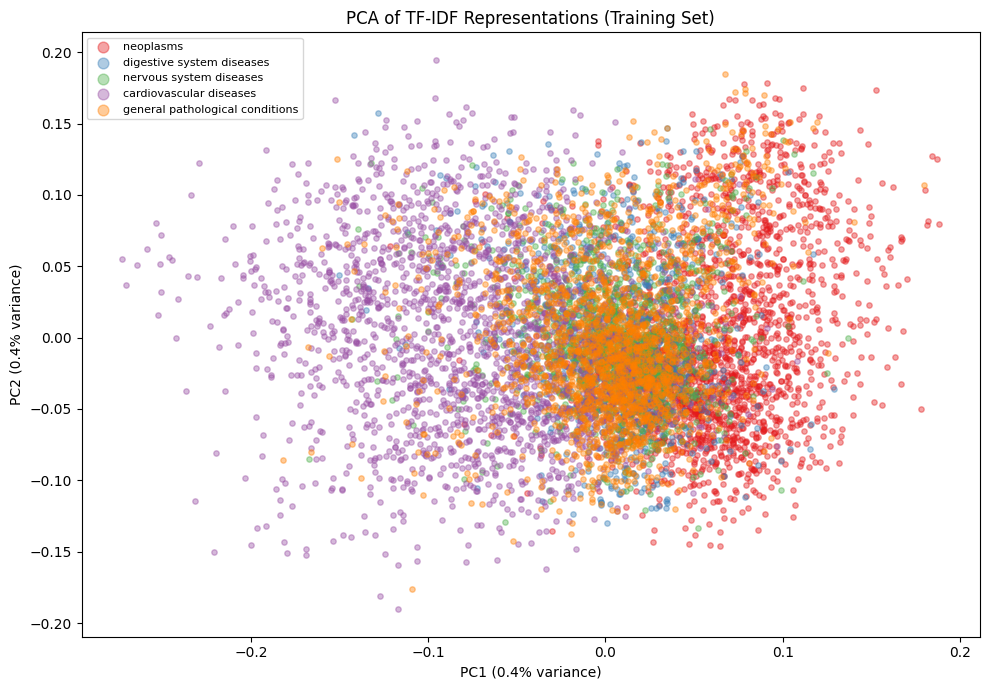

In [17]:
# PCA visualisation of TF-IDF vectors
from sklearn.decomposition import PCA

tfidf_matrix = pipe_tfidf_svc_prep.named_steps['tfidf'].transform(X_train_prep)
pca = PCA(n_components=2)
tfidf_2d = pca.fit_transform(tfidf_matrix.toarray())

fig, ax = plt.subplots(figsize=(10, 7))
colours = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for idx, label in enumerate(sorted(train_df['condition_label'].unique())):
    mask = y_train == label
    ax.scatter(tfidf_2d[mask, 0], tfidf_2d[mask, 1],
               c=colours[idx], s=15, alpha=0.4, label=label_map[label])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA of TF-IDF Representations (Training Set)')
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

I can see some structure - neoplasms (red) tends to cluster towards the right side of PC1, while cardiovascular diseases (purple) leans towards the left. General pathological conditions (orange) is spread across the entire plot with heavy overlap into every other class, which explains why it's the hardest category to classify. The massive overlap in the centre is typical of TF-IDF on high-dimensional data. I suppose the real separation exists across thousands of dimensions that PCA can't show in 2D.

***
### 2.3 Representation Learning - Sentence Transformer Embeddings

TF-IDF is a bag-of-words approach that can't capture semantic meaning. It treats each token independently and doesn't understand context. For comparison, I also use a pre-trained Sentence Transformer model (all-MiniLM-L6-v2) which produces 384-dimensional dense vectors that encode the meaning of entire sentences.

This follows the same principle as the GloVe embeddings from Lab 07 - using pre-trained representations rather than training our own - but uses a more advanced transformer architecture. Unlike GloVe which averages individual word vectors, the Sentence Transformer processes the full sentence and understands context, so a word like "discharge" can mean different things in cardiology versus hospital admin contexts.

I wrapped the model as a sklearn transformer class (similar to the `glove_rep` class from Lab 07) so it integrates with the same evaluation pipeline. I tested this on both raw and preprocessed text to see which input works better - the model has its own internal tokeniser, so preprocessing may actually hurt rather than help.

In [18]:
# 2.3 Representation Learning: Sentence Transformer (all-MiniLM-L6-v2)
import warnings, os, logging
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

from sentence_transformers import SentenceTransformer

class SentTransformerEmbedder(BaseEstimator, TransformerMixin):
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model_name = model_name
        self.model = None

    def fit(self, X, y=None):
        if self.model is None:
            print(f"Loading model: {self.model_name}...")
            self.model = SentenceTransformer(self.model_name)
        return self

    def transform(self, X, y=None):
        return self.model.encode(X, show_progress_bar=True, batch_size=64)

In [19]:
# Encode raw and preprocessed text with Sentence Transformer
embedder = SentTransformerEmbedder()
embedder.fit(None)

print("Encoding raw training set...")
X_train_st_raw = embedder.transform(X_train)
print("Encoding raw test set...")
X_test_st_raw = embedder.transform(X_test)

print("\nEncoding preprocessed training set...")
X_train_st_prep = embedder.transform(X_train_prep)
print("Encoding preprocessed test set...")
X_test_st_prep = embedder.transform(X_test_prep)

print(f"\nRaw embeddings:  train={X_train_st_raw.shape}, test={X_test_st_raw.shape}")
print(f"Prep embeddings: train={X_train_st_prep.shape}, test={X_test_st_prep.shape}")

Loading model: all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...


Encoding preprocessed training set...


Batches:   0%|          | 0/133 [00:00<?, ?it/s]

Encoding preprocessed test set...


Batches:   0%|          | 0/46 [00:00<?, ?it/s]


Raw embeddings:  train=(8457, 384), test=(2888, 384)
Prep embeddings: train=(8457, 384), test=(2888, 384)


In [20]:
# ST + LinearSVC (raw and preprocessed)
svc_st_raw = LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=123)
svc_st_raw.fit(X_train_st_raw, y_train)
preds_st_svc_raw = svc_st_raw.predict(X_test_st_raw)

svc_st_prep = LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=123)
svc_st_prep.fit(X_train_st_prep, y_train)
preds_st_svc_prep = svc_st_prep.predict(X_test_st_prep)

print("ST + LinearSVC (raw)")
print(f"Accuracy: {accuracy_score(y_test, preds_st_svc_raw):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_st_svc_raw, average='macro'):.4f}")
print(classification_report(y_test, preds_st_svc_raw, target_names=labels_df['condition_name'].tolist()))

print("\nST + LinearSVC (preprocessed)")
print(f"Accuracy: {accuracy_score(y_test, preds_st_svc_prep):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_st_svc_prep, average='macro'):.4f}")
print(classification_report(y_test, preds_st_svc_prep, target_names=labels_df['condition_name'].tolist()))

ST + LinearSVC (raw)
Accuracy: 0.6333
Macro F1: 0.6317
                                 precision    recall  f1-score   support

                      neoplasms       0.69      0.83      0.76       633
      digestive system diseases       0.53      0.78      0.63       299
        nervous system diseases       0.56      0.68      0.61       385
        cardiovascular diseases       0.66      0.83      0.73       610
general pathological conditions       0.68      0.31      0.43       961

                       accuracy                           0.63      2888
                      macro avg       0.62      0.69      0.63      2888
                   weighted avg       0.65      0.63      0.61      2888


ST + LinearSVC (preprocessed)
Accuracy: 0.6260
Macro F1: 0.6253
                                 precision    recall  f1-score   support

                      neoplasms       0.69      0.82      0.75       633
      digestive system diseases       0.52      0.78      0.62       299


In [21]:
# ST + Logistic Regression (raw and preprocessed)
lr_st_raw = LogisticRegression(C=1.0, max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=123)
lr_st_raw.fit(X_train_st_raw, y_train)
preds_st_lr_raw = lr_st_raw.predict(X_test_st_raw)

lr_st_prep = LogisticRegression(C=1.0, max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=123)
lr_st_prep.fit(X_train_st_prep, y_train)
preds_st_lr_prep = lr_st_prep.predict(X_test_st_prep)

print("ST + Logistic Regression (raw)")
print(f"Accuracy: {accuracy_score(y_test, preds_st_lr_raw):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_st_lr_raw, average='macro'):.4f}")
print(classification_report(y_test, preds_st_lr_raw, target_names=labels_df['condition_name'].tolist()))

print("\nST + Logistic Regression (preprocessed)")
print(f"Accuracy: {accuracy_score(y_test, preds_st_lr_prep):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_st_lr_prep, average='macro'):.4f}")
print(classification_report(y_test, preds_st_lr_prep, target_names=labels_df['condition_name'].tolist()))

ST + Logistic Regression (raw)
Accuracy: 0.6260
Macro F1: 0.6270
                                 precision    recall  f1-score   support

                      neoplasms       0.71      0.79      0.75       633
      digestive system diseases       0.50      0.80      0.62       299
        nervous system diseases       0.54      0.70      0.61       385
        cardiovascular diseases       0.67      0.80      0.73       610
general pathological conditions       0.65      0.32      0.43       961

                       accuracy                           0.63      2888
                      macro avg       0.61      0.68      0.63      2888
                   weighted avg       0.64      0.63      0.61      2888


ST + Logistic Regression (preprocessed)
Accuracy: 0.6250
Macro F1: 0.6270
                                 precision    recall  f1-score   support

                      neoplasms       0.71      0.79      0.75       633
      digestive system diseases       0.50      0.81 

In [22]:
# ST + MLP (raw and preprocessed)
from sklearn.neural_network import MLPClassifier

mlp_st_raw = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
                            max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=123)
mlp_st_raw.fit(X_train_st_raw, y_train)
preds_st_mlp_raw = mlp_st_raw.predict(X_test_st_raw)

mlp_st_prep = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
                             max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=123)
mlp_st_prep.fit(X_train_st_prep, y_train)
preds_st_mlp_prep = mlp_st_prep.predict(X_test_st_prep)

print("ST + MLP (raw)")
print(f"Accuracy: {accuracy_score(y_test, preds_st_mlp_raw):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_st_mlp_raw, average='macro'):.4f}")
print(classification_report(y_test, preds_st_mlp_raw, target_names=labels_df['condition_name'].tolist()))

print("\nST + MLP (preprocessed)")
print(f"Accuracy: {accuracy_score(y_test, preds_st_mlp_prep):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_st_mlp_prep, average='macro'):.4f}")
print(classification_report(y_test, preds_st_mlp_prep, target_names=labels_df['condition_name'].tolist()))

ST + MLP (raw)
Accuracy: 0.6385
Macro F1: 0.6352
                                 precision    recall  f1-score   support

                      neoplasms       0.68      0.87      0.76       633
      digestive system diseases       0.54      0.71      0.61       299
        nervous system diseases       0.60      0.63      0.61       385
        cardiovascular diseases       0.66      0.83      0.74       610
general pathological conditions       0.65      0.34      0.45       961

                       accuracy                           0.64      2888
                      macro avg       0.62      0.68      0.64      2888
                   weighted avg       0.64      0.64      0.62      2888


ST + MLP (preprocessed)
Accuracy: 0.6361
Macro F1: 0.6336
                                 precision    recall  f1-score   support

                      neoplasms       0.69      0.85      0.76       633
      digestive system diseases       0.54      0.71      0.61       299
        nerv

The clustering patterns are mostly similar - neoplasms (red) pulls to the right, cardiovascular diseases (purple) to the left. But the classes are more spread out and the boundaries between them are no clearer than with TF-IDF. General pathological conditions (orange) again dominates the centre and overlaps heavily with all other classes. Despite the denser representation capturing more semantic meaning, TF-IDF still achieves higher classification accuracy on this task, suggesting that the medical vocabulary is a stronger signal than sentence semantics for aligning articles to the correct department.

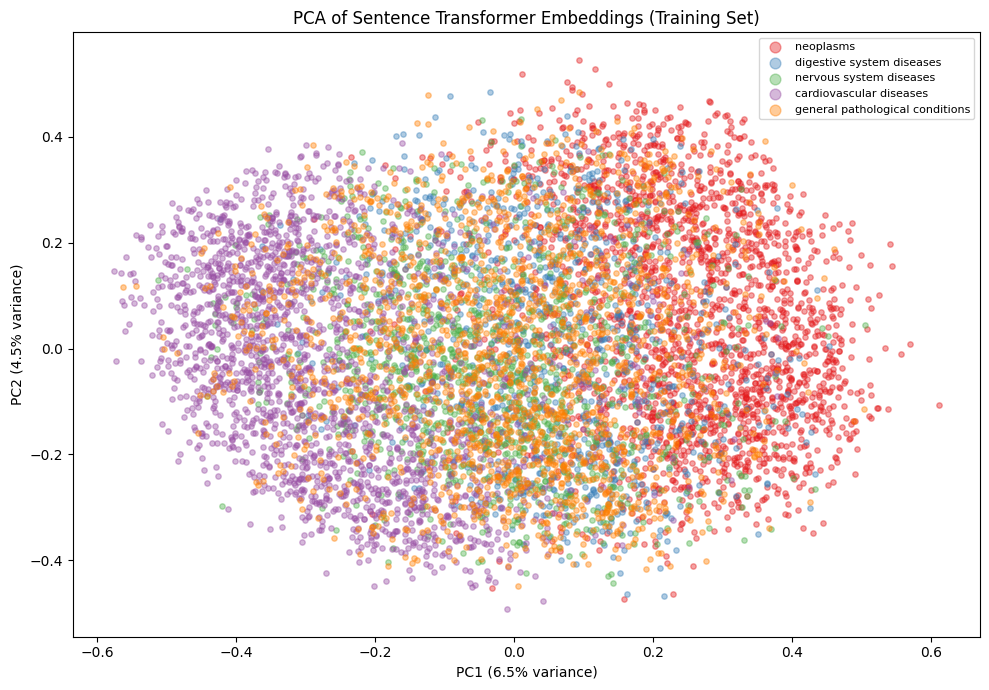

In [23]:
# PCA visualisation of Sentence Transformer embeddings
pca_st = PCA(n_components=2)
st_2d = pca_st.fit_transform(X_train_st_raw)

fig, ax = plt.subplots(figsize=(10, 7))
for idx, label in enumerate(sorted(train_df['condition_label'].unique())):
    mask = y_train == label
    ax.scatter(st_2d[mask, 0], st_2d[mask, 1],
               c=colours[idx], s=15, alpha=0.4, label=label_map[label])
ax.set_xlabel(f'PC1 ({pca_st.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_st.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA of Sentence Transformer Embeddings (Training Set)')
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

***
### 2.4 PubMedBERT

The LinearSVC and Logistic Regression classifiers are both linear models. To extend the comparison, I also tested a Multi-Layer Perceptron (MLP) neural network, which was introduced in Week 6. An MLP can learn non-linear decision boundaries through its hidden layers and activation functions, which could potentially capture more complex relationships between the embedding features and the condition categories.

I'm only applying the MLP to the Sentence Transformer embeddings (not TF-IDF) because MLP struggles with the high-dimensional sparse vectors that TF-IDF produces - it would be very slow to train and prone to overfitting on 30,000 sparse features. The 384-dimensional dense embeddings from the Sentence Transformer are a much better fit for a neural network input.

I used SKLearn's MLPClassifier with two hidden layers (256 and 128 neurons), ReLU activation, and early stopping to prevent overfitting. The architecture gradually reduces dimensionality from the 384-dimensional input through to the 5 output classes, which follows the same principle as the encoder side of the transformer architectures discussed in Week 5.

In [24]:
# 2.4 Representation Learning: PubMedBERT (Domain-Specific Transformer)
import torch, time
from sentence_transformers import SentenceTransformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("Loading PubMedBERT (S-PubMedBert-MS-MARCO)...")
pubmedbert = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO', device=device)
pubmedbert.max_seq_length = 512
print(f"Model loaded. Embedding dim: {pubmedbert.get_sentence_embedding_dimension()}")

Using device: cuda
Loading PubMedBERT (S-PubMedBert-MS-MARCO)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded. Embedding dim: 768


/tmp/ipykernel_6851/906301728.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded. Embedding dim: {pubmedbert.get_sentence_embedding_dimension()}")


In [25]:
# Encode raw and preprocessed text with PubMedBERT
print("Encoding raw training set with PubMedBERT...")
start = time.time()
X_train_pm_raw = pubmedbert.encode(X_train, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
print(f"  Time: {time.time()-start:.1f}s")

print("Encoding raw test set...")
start = time.time()
X_test_pm_raw = pubmedbert.encode(X_test, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
print(f"  Time: {time.time()-start:.1f}s")

print("\nEncoding preprocessed training set...")
start = time.time()
X_train_pm_prep = pubmedbert.encode(X_train_prep, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
print(f"  Time: {time.time()-start:.1f}s")

print("Encoding preprocessed test set...")
start = time.time()
X_test_pm_prep = pubmedbert.encode(X_test_prep, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
print(f"  Time: {time.time()-start:.1f}s")

print(f"\nRaw:  train={X_train_pm_raw.shape}, test={X_test_pm_raw.shape}")
print(f"Prep: train={X_train_pm_prep.shape}, test={X_test_pm_prep.shape}")

Encoding raw training set with PubMedBERT...


Batches:   0%|          | 0/265 [00:00<?, ?it/s]

  Time: 68.6s
Encoding raw test set...


Batches:   0%|          | 0/91 [00:00<?, ?it/s]

  Time: 24.2s

Encoding preprocessed training set...


Batches:   0%|          | 0/265 [00:00<?, ?it/s]

  Time: 36.8s
Encoding preprocessed test set...


Batches:   0%|          | 0/91 [00:00<?, ?it/s]

  Time: 12.2s

Raw:  train=(8457, 768), test=(2888, 768)
Prep: train=(8457, 768), test=(2888, 768)


In [26]:
# PubMedBERT + LinearSVC (raw and preprocessed)
svc_pm_raw = LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=123)
svc_pm_raw.fit(X_train_pm_raw, y_train)
preds_pm_svc_raw = svc_pm_raw.predict(X_test_pm_raw)

svc_pm_prep = LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=123)
svc_pm_prep.fit(X_train_pm_prep, y_train)
preds_pm_svc_prep = svc_pm_prep.predict(X_test_pm_prep)

print("PubMedBERT + LinearSVC (raw)")
print(f"Accuracy: {accuracy_score(y_test, preds_pm_svc_raw):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_pm_svc_raw, average='macro'):.4f}")
print(classification_report(y_test, preds_pm_svc_raw, target_names=labels_df['condition_name'].tolist()))

print("\nPubMedBERT + LinearSVC (preprocessed)")
print(f"Accuracy: {accuracy_score(y_test, preds_pm_svc_prep):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_pm_svc_prep, average='macro'):.4f}")
print(classification_report(y_test, preds_pm_svc_prep, target_names=labels_df['condition_name'].tolist()))

PubMedBERT + LinearSVC (raw)
Accuracy: 0.6295
Macro F1: 0.6266
                                 precision    recall  f1-score   support

                      neoplasms       0.70      0.83      0.76       633
      digestive system diseases       0.50      0.74      0.60       299
        nervous system diseases       0.57      0.68      0.62       385
        cardiovascular diseases       0.64      0.83      0.72       610
general pathological conditions       0.67      0.32      0.43       961

                       accuracy                           0.63      2888
                      macro avg       0.62      0.68      0.63      2888
                   weighted avg       0.64      0.63      0.61      2888


PubMedBERT + LinearSVC (preprocessed)
Accuracy: 0.6250
Macro F1: 0.6219
                                 precision    recall  f1-score   support

                      neoplasms       0.70      0.83      0.76       633
      digestive system diseases       0.50      0.73     

In [27]:
# PubMedBERT + MLP (raw and preprocessed)
mlp_pm_raw = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
                            max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=123)
mlp_pm_raw.fit(X_train_pm_raw, y_train)
preds_pm_mlp_raw = mlp_pm_raw.predict(X_test_pm_raw)

mlp_pm_prep = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
                             max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=123)
mlp_pm_prep.fit(X_train_pm_prep, y_train)
preds_pm_mlp_prep = mlp_pm_prep.predict(X_test_pm_prep)

print("PubMedBERT + MLP (raw)")
print(f"Accuracy: {accuracy_score(y_test, preds_pm_mlp_raw):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_pm_mlp_raw, average='macro'):.4f}")
print(classification_report(y_test, preds_pm_mlp_raw, target_names=labels_df['condition_name'].tolist()))

print("\nPubMedBERT + MLP (preprocessed)")
print(f"Accuracy: {accuracy_score(y_test, preds_pm_mlp_prep):.4f}")
print(f"Macro F1: {f1_score(y_test, preds_pm_mlp_prep, average='macro'):.4f}")
print(classification_report(y_test, preds_pm_mlp_prep, target_names=labels_df['condition_name'].tolist()))

PubMedBERT + MLP (raw)
Accuracy: 0.6454
Macro F1: 0.6443
                                 precision    recall  f1-score   support

                      neoplasms       0.71      0.84      0.77       633
      digestive system diseases       0.52      0.83      0.64       299
        nervous system diseases       0.61      0.68      0.64       385
        cardiovascular diseases       0.65      0.86      0.74       610
general pathological conditions       0.70      0.31      0.43       961

                       accuracy                           0.65      2888
                      macro avg       0.64      0.70      0.64      2888
                   weighted avg       0.66      0.65      0.62      2888


PubMedBERT + MLP (preprocessed)
Accuracy: 0.6337
Macro F1: 0.6307
                                 precision    recall  f1-score   support

                      neoplasms       0.66      0.88      0.75       633
      digestive system diseases       0.52      0.78      0.62       

***
### 2.5 Cross-Validation
Running 5-fold cross-validation on the training set to check the results are stable and not just lucky on one split. This follows the same approach as Lab 06/07.

In [28]:
# 2.5 Cross-Validation
cv_results = {}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# TF-IDF pipelines (re-fit during CV)
for name, pipe, data in [
    ('TF-IDF+SVC (raw)', pipe_tfidf_svc_raw, X_train),
    ('TF-IDF+SVC (prep)', pipe_tfidf_svc_prep, X_train_prep),
    ('TF-IDF+LR (raw)', pipe_tfidf_lr_raw, X_train),
    ('TF-IDF+LR (prep)', pipe_tfidf_lr_prep, X_train_prep),
]:
    print(f"CV: {name}...")
    scores = cross_val_score(pipe, data, y_train, cv=kf, scoring='f1_macro')
    cv_results[name] = scores
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")

# ST classifiers (embeddings pre-computed)
for name, clf, data in [
    ('ST+SVC (raw)', LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=123), X_train_st_raw),
    ('ST+SVC (prep)', LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=123), X_train_st_prep),
    ('ST+LR (raw)', LogisticRegression(C=1.0, max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=123), X_train_st_raw),
    ('ST+LR (prep)', LogisticRegression(C=1.0, max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=123), X_train_st_prep),
    ('ST+MLP (raw)', MLPClassifier(hidden_layer_sizes=(256,128), activation='relu', solver='adam', max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=123), X_train_st_raw),
    ('ST+MLP (prep)', MLPClassifier(hidden_layer_sizes=(256,128), activation='relu', solver='adam', max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=123), X_train_st_prep),
]:
    print(f"CV: {name}...")
    scores = cross_val_score(clf, data, y_train, cv=kf, scoring='f1_macro')
    cv_results[name] = scores
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")

# PubMedBERT classifiers
for name, clf, data in [
    ('PM+SVC (raw)', LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=123), X_train_pm_raw),
    ('PM+SVC (prep)', LinearSVC(C=1.0, max_iter=5000, class_weight='balanced', random_state=123), X_train_pm_prep),
    ('PM+MLP (raw)', MLPClassifier(hidden_layer_sizes=(256,128), activation='relu', solver='adam', max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=123), X_train_pm_raw),
    ('PM+MLP (prep)', MLPClassifier(hidden_layer_sizes=(256,128), activation='relu', solver='adam', max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=123), X_train_pm_prep),
]:
    print(f"CV: {name}...")
    scores = cross_val_score(clf, data, y_train, cv=kf, scoring='f1_macro')
    cv_results[name] = scores
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")

CV: TF-IDF+SVC (raw)...
  Mean: 0.7708 (+/- 0.0109)
CV: TF-IDF+SVC (prep)...
  Mean: 0.7771 (+/- 0.0043)
CV: TF-IDF+LR (raw)...
  Mean: 0.7534 (+/- 0.0123)
CV: TF-IDF+LR (prep)...
  Mean: 0.7638 (+/- 0.0101)
CV: ST+SVC (raw)...
  Mean: 0.7492 (+/- 0.0145)
CV: ST+SVC (prep)...
  Mean: 0.7474 (+/- 0.0117)
CV: ST+LR (raw)...
  Mean: 0.7490 (+/- 0.0140)
CV: ST+LR (prep)...
  Mean: 0.7441 (+/- 0.0114)
CV: ST+MLP (raw)...
  Mean: 0.7529 (+/- 0.0065)
CV: ST+MLP (prep)...
  Mean: 0.7503 (+/- 0.0059)
CV: PM+SVC (raw)...
  Mean: 0.7498 (+/- 0.0066)
CV: PM+SVC (prep)...
  Mean: 0.7403 (+/- 0.0117)
CV: PM+MLP (raw)...
  Mean: 0.7580 (+/- 0.0113)
CV: PM+MLP (prep)...
  Mean: 0.7476 (+/- 0.0044)


***
## Section 3: Business Case - Results and Discussion

### 3.1 Results Summary

I tested each representation method (TF-IDF and Sentence Transformer) with each classifier (LinearSVC, Logistic Regression, and MLP where appropriate), on both raw and preprocessed text - giving 10 combinations total. The table below shows all results sorted by Macro F1.

In [29]:
# 3.1 Results Summary Table
all_preds = {
    'TF-IDF+SVC (raw)': preds_tfidf_svc_raw,
    'TF-IDF+SVC (prep)': preds_tfidf_svc_prep,
    'TF-IDF+LR (raw)': preds_tfidf_lr_raw,
    'TF-IDF+LR (prep)': preds_tfidf_lr_prep,
    'ST+SVC (raw)': preds_st_svc_raw,
    'ST+SVC (prep)': preds_st_svc_prep,
    'ST+LR (raw)': preds_st_lr_raw,
    'ST+LR (prep)': preds_st_lr_prep,
    'ST+MLP (raw)': preds_st_mlp_raw,
    'ST+MLP (prep)': preds_st_mlp_prep,
    'PM+SVC (raw)': preds_pm_svc_raw,
    'PM+SVC (prep)': preds_pm_svc_prep,
    'PM+MLP (raw)': preds_pm_mlp_raw,
    'PM+MLP (prep)': preds_pm_mlp_prep,
}

rows = []
for name, preds in all_preds.items():
    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Macro F1': round(f1_score(y_test, preds, average='macro'), 4),
        'Weighted F1': round(f1_score(y_test, preds, average='weighted'), 4),
    })

results_df = pd.DataFrame(rows).sort_values('Macro F1', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Macro F1,Weighted F1
0,TF-IDF+SVC (prep),0.6620,0.6617,0.6455
1,TF-IDF+LR (prep),0.6506,0.6520,0.6343
2,TF-IDF+SVC (raw),0.6513,0.6507,0.6349
3,PM+MLP (raw),0.6454,0.6443,0.6199
4,ST+MLP (raw),0.6385,0.6352,0.6177
5,TF-IDF+LR (raw),0.6326,0.6340,0.6161
6,ST+MLP (prep),0.6361,0.6336,0.6186
7,ST+SVC (raw),0.6333,0.6317,0.6097
8,PM+MLP (prep),0.6337,0.6307,0.6067
9,ST+LR (raw),0.6260,0.6270,0.6061


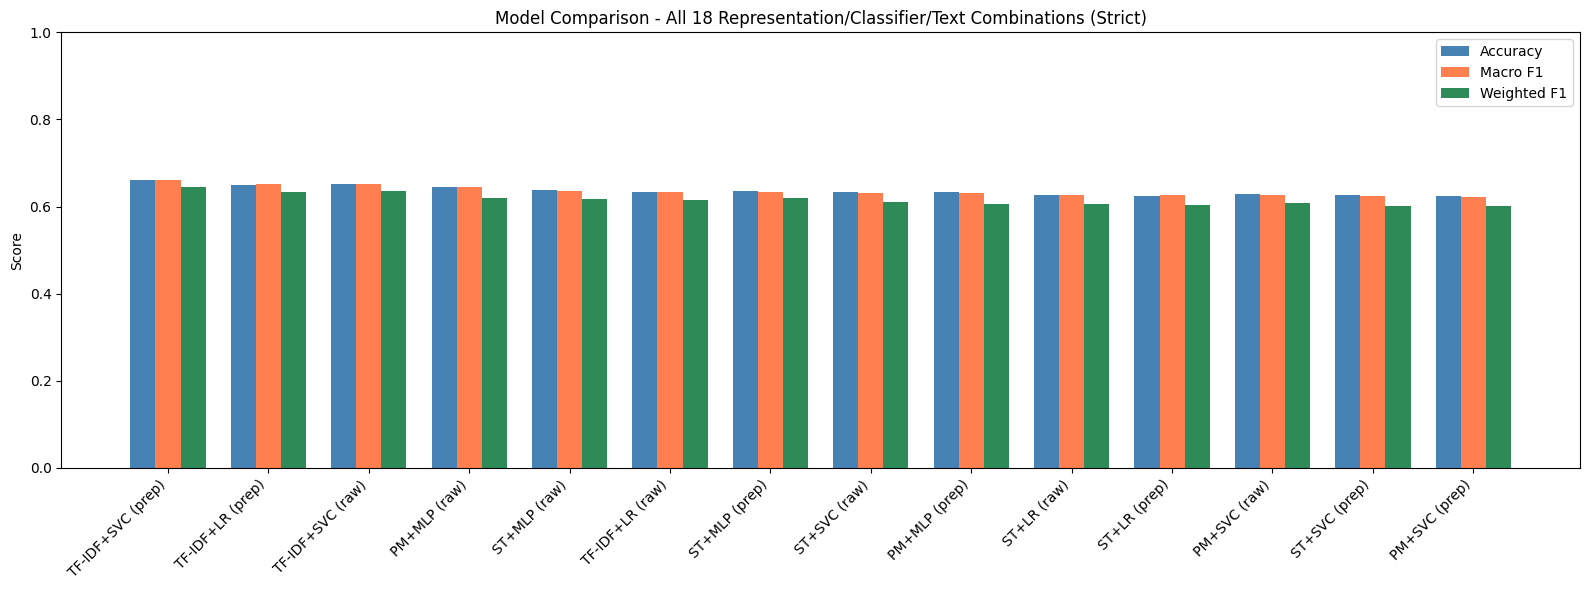

In [30]:
# Results bar chart
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(results_df))
w = 0.25

ax.bar(x - w, results_df['Accuracy'], w, label='Accuracy', color='steelblue')
ax.bar(x, results_df['Macro F1'], w, label='Macro F1', color='coral')
ax.bar(x + w, results_df['Weighted F1'], w, label='Weighted F1', color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison - All 18 Representation/Classifier/Text Combinations (Strict)')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

***
### 3.2 Lenient Evaluation

In [31]:
# 3.2 Lenient Evaluation
# Build valid-label lookup from the COMPLETE unmodified dataset
all_data_orig = pd.concat([
    pd.read_csv(train_file_path)[['condition_label', 'medical_abstract']],
    pd.read_csv(test_file_path)[['condition_label', 'medical_abstract']]
])
valid_labels = all_data_orig.groupby('medical_abstract')['condition_label'].apply(set).to_dict()

# Compute lenient results for all models
rows_lenient = []
for name, preds in all_preds.items():
    # Build lenient y_true
    y_lenient = y_test.copy()
    for i in range(len(y_test)):
        if preds[i] != y_test[i] and preds[i] in valid_labels.get(X_test[i], {y_test[i]}):
            y_lenient[i] = preds[i]

    rows_lenient.append({
        'Model': name,
        'Strict F1': round(f1_score(y_test, preds, average='macro'), 4),
        'Lenient F1': round(f1_score(y_lenient, preds, average='macro'), 4),
        'Strict Acc': round(accuracy_score(y_test, preds), 4),
        'Lenient Acc': round(accuracy_score(y_lenient, preds), 4),
    })

lenient_df = pd.DataFrame(rows_lenient).sort_values('Lenient F1', ascending=False).reset_index(drop=True)
lenient_df

,Model,Strict F1,Lenient F1,Strict Acc,Lenient Acc
0,TF-IDF+SVC (prep),0.6617,0.8697,0.6620,0.8740
1,TF-IDF+SVC (raw),0.6507,0.8541,0.6513,0.8584
2,TF-IDF+LR (prep),0.6520,0.8529,0.6506,0.8573
3,ST+MLP (raw),0.6352,0.8426,0.6385,0.8497
4,ST+MLP (prep),0.6336,0.8405,0.6361,0.8473
5,PM+MLP (raw),0.6443,0.8376,0.6454,0.8483
6,TF-IDF+LR (raw),0.6340,0.8361,0.6326,0.8407
7,ST+SVC (raw),0.6317,0.8339,0.6333,0.8435
8,ST+LR (raw),0.6270,0.8293,0.6260,0.8369
9,PM+SVC (raw),0.6266,0.8282,0.6295,0.8376


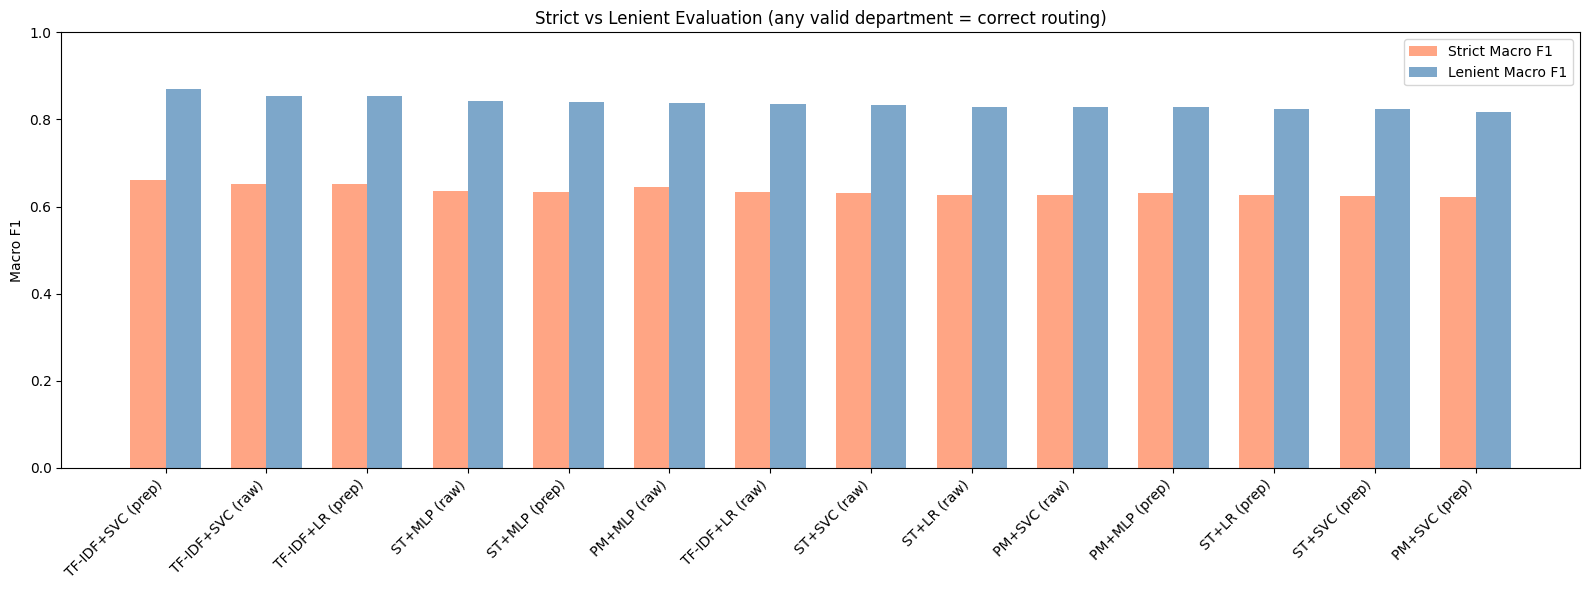

In [32]:
# Side-by-side strict vs lenient bar chart
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(lenient_df))
w = 0.35

ax.bar(x - w/2, lenient_df['Strict F1'], w, label='Strict Macro F1', color='coral', alpha=0.7)
ax.bar(x + w/2, lenient_df['Lenient F1'], w, label='Lenient Macro F1', color='steelblue', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(lenient_df['Model'], rotation=45, ha='right')
ax.set_ylabel('Macro F1')
ax.set_title('Strict vs Lenient Evaluation (any valid department = correct routing)')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

***
### 3.3 Confusion Matrices

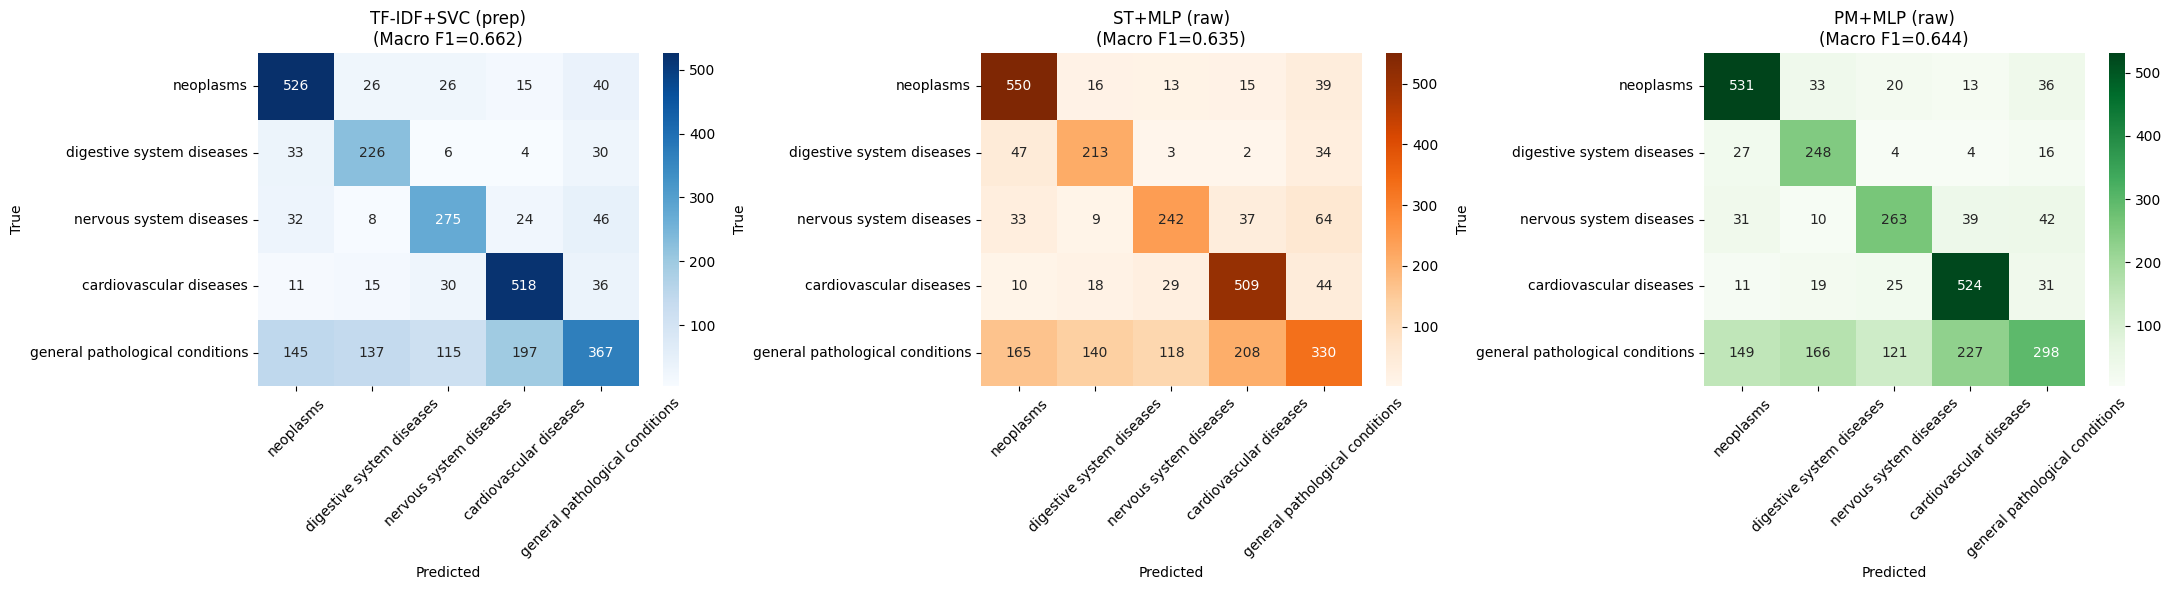

In [33]:
# 3.3 Confusion Matrices (best model from each representation)
# Pick the best from each family by strict Macro F1
best_tfidf_name = results_df[results_df['Model'].str.startswith('TF-IDF')].iloc[0]['Model']
best_st_name = results_df[results_df['Model'].str.startswith('ST')].iloc[0]['Model']
best_pm_name = results_df[results_df['Model'].str.startswith('PM')].iloc[0]['Model']

class_names = labels_df['condition_name'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, name, cmap in zip(axes, [best_tfidf_name, best_st_name, best_pm_name], ['Blues', 'Oranges', 'Greens']):
    cm = confusion_matrix(y_test, all_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    f1 = f1_score(y_test, all_preds[name], average='macro')
    ax.set_title(f'{name}\n(Macro F1={f1:.3f})')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The confusion matrices show a consistent pattern across all three representations. Labels 1-4 have strong diagonals (526, 226, 275, 518 for TF-IDF+SVC). General pathological conditions is the outlier: of 961 test rows, only 367 are correctly predicted. The remaining 594 are scattered across the four specific departments. However, the lenient evaluation in Section 3.2 shows that the majority of these "errors" are clinically valid predictions - the model is routing to a department the abstract genuinely belongs to.

***
### 3.4 Cross-Validation Stability

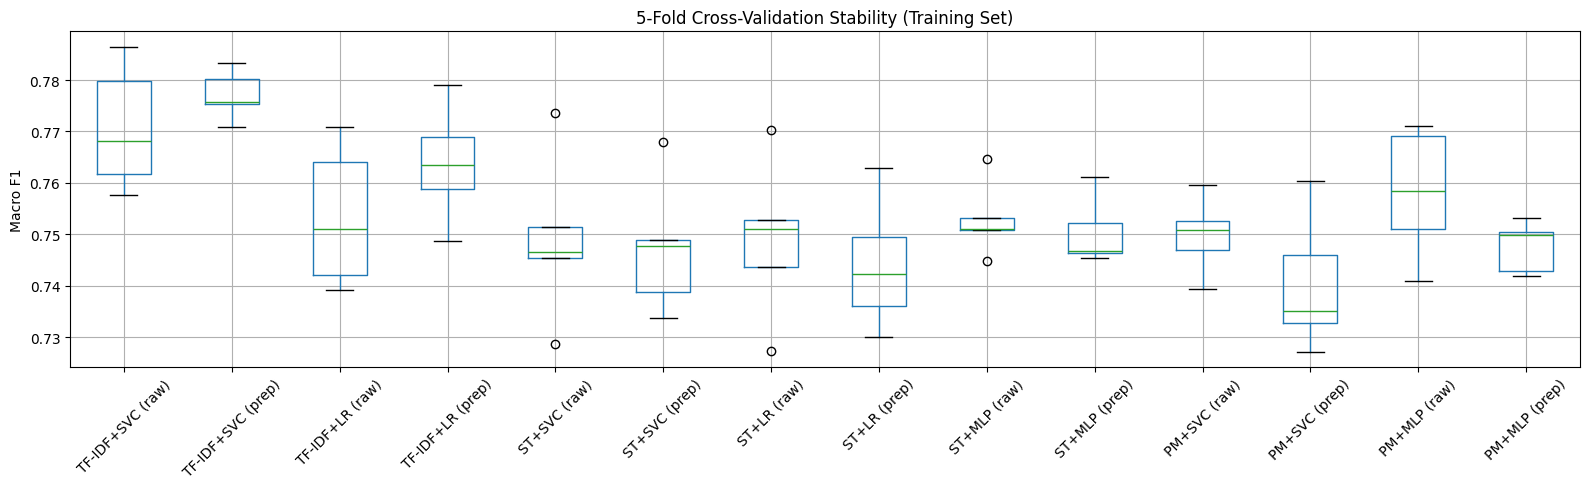

In [34]:
# 3.4 Cross-Validation Stability
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(16, 5))
cv_df.boxplot(ax=ax)
ax.set_ylabel('Macro F1')
ax.set_title('5-Fold Cross-Validation Stability (Training Set)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

***
### 3.5 Per-Class F1 Breakdown
This is important for MediPublish as they need reliable aligning of articles across all 5 departments, not just the biggest ones.

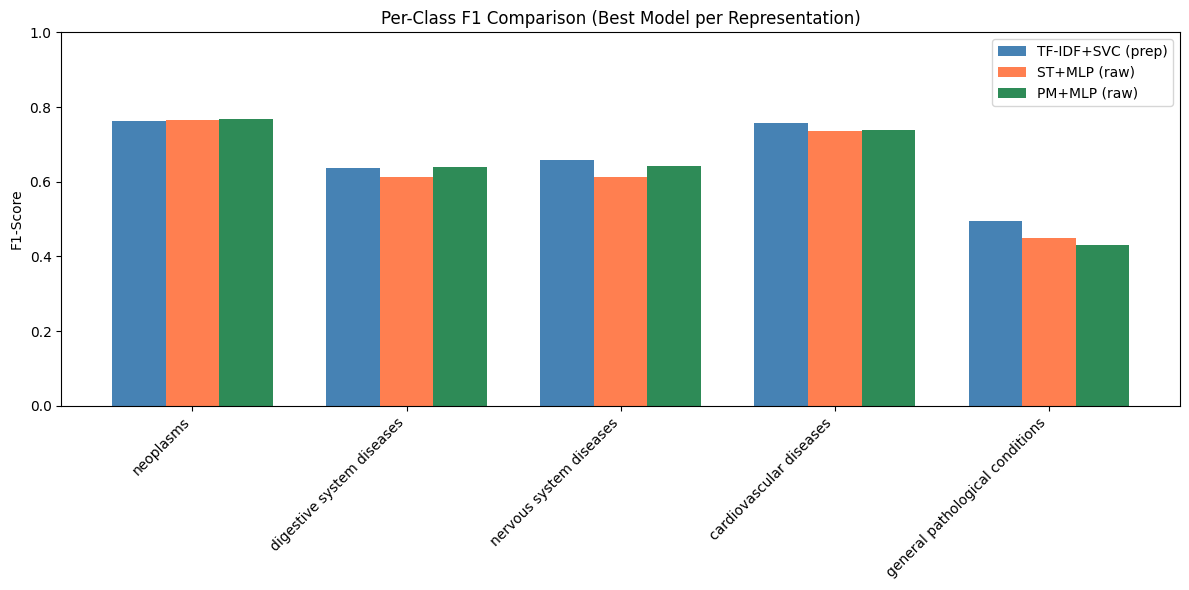

In [35]:
# 3.5 Per-Class F1 (best model from each representation)
class_labels = labels_df['condition_label'].tolist()

f1_tfidf = f1_score(y_test, all_preds[best_tfidf_name], average=None, labels=class_labels)
f1_st = f1_score(y_test, all_preds[best_st_name], average=None, labels=class_labels)
f1_pm = f1_score(y_test, all_preds[best_pm_name], average=None, labels=class_labels)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
w = 0.25

ax.bar(x - w, f1_tfidf, w, label=best_tfidf_name, color='steelblue')
ax.bar(x, f1_st, w, label=best_st_name, color='coral')
ax.bar(x + w, f1_pm, w, label=best_pm_name, color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1 Comparison (Best Model per Representation)')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

***
### 3.6 Per-Class Recall Breakdown
This is important for MediPublish as low recall means articles are being missed.

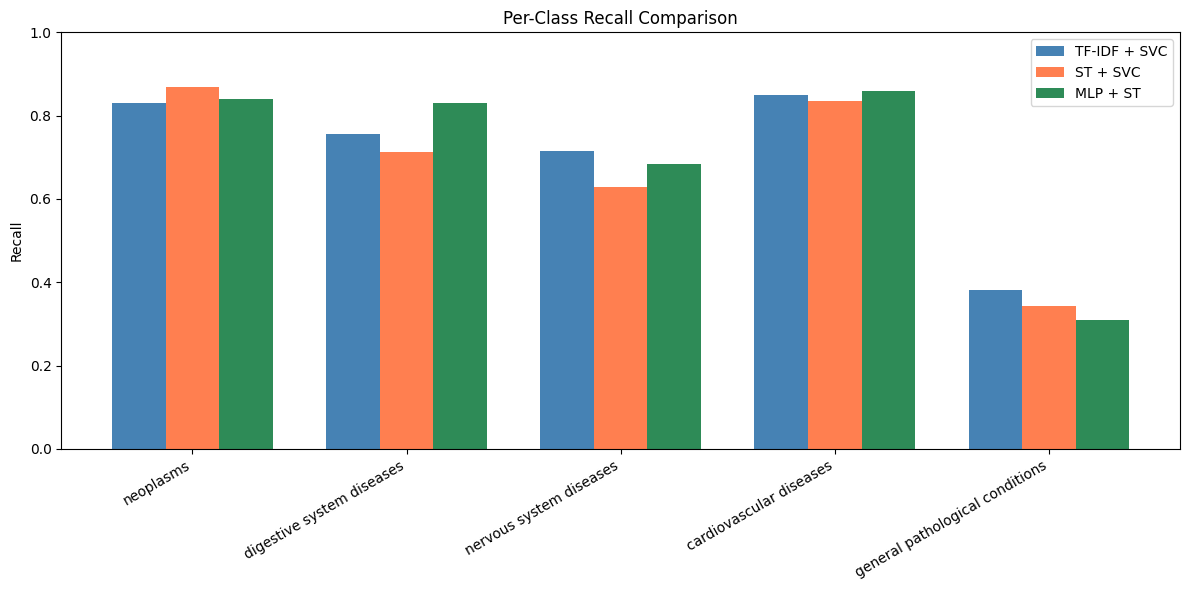

In [36]:
# 3.5 Per-Class recall (best model from each representation)
recall_tfidf = recall_score(y_test, all_preds[best_tfidf_name], average=None, labels=class_labels)
recall_st = recall_score(y_test, all_preds[best_st_name], average=None, labels=class_labels)
recall_mlp = recall_score(y_test, all_preds[best_pm_name], average=None, labels=class_labels)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
w = 0.25

ax.bar(x - w, recall_tfidf, w, label='TF-IDF + SVC', color='steelblue')
ax.bar(x,     recall_st,    w, label='ST + SVC', color='coral')
ax.bar(x + w, recall_mlp,   w, label='MLP + ST', color='seagreen')

ax.set_ylabel('Recall')
ax.set_title('Per-Class Recall Comparison')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

***

## Summary and Conclusion

The best-performing model is TF-IDF + LinearSVC on preprocessed text, achieving 0.66 macro F1 under strict evaluation and 0.87 under lenient evaluation. Cross-validation confirms stability (mean CV F1 = 0.78, std = 0.004).

Three key findings from the comparative study:

1. **TF-IDF outperforms both Sentence Transformer and PubMedBERT** on this task. Medical abstracts use distinctive vocabulary - terms like "carcinoma", "coronary", and "hepatitis" are strong department indicators, and TF-IDF captures these word-frequency signals directly. The semantic understanding of transformer embeddings provides no additional benefit here, likely because the classification task depends on vocabulary presence rather than contextual meaning.

2. The gap between CV performance (0.78) and strict test performance (0.66) is explained by label noise, not overfitting. 41% of test abstracts have multiple valid labels across the dataset, but the test set assigns only one. Under lenient evaluation - where routing to any valid department counts as correct - all models jump to 0.82-0.87, closely matching CV scores.

3. General pathological conditions (label 5) is the main challenge, achieving only 0.50 F1 and 0.38 recall under strict evaluation. Only 474 of the 961 test rows labelled as class 5 are exclusively general pathology - the remaining 487 also belong to specific departments. The model correctly identifies them as specific, but gets penalised. Labels 1-4 individually achieve 0.64-0.76 F1, confirming the pipeline works well for department-specific routing.

For MediPublish, this pipeline is fit for purpose as a first-line article routing system. Under lenient evaluation - the metric that matches the real business requirement of sending articles to a valid department - the system achieves 87% accuracy. The label 5 limitation reflects a genuine multi-label characteristic of medical literature, and a multi-label classification approach would be the natural next step.

***
##GenAI Statement

GenAI was used to support completion of this assessment. It was used for ideas and some code error checking.

Specifically, GenAI was used for:
- Ideas: Discussing which visualisations to include, and planning some notebook structure.
- Editing: Reviewing code for consistency (e.g. ensuring confusion matrix variable names matched the correct model variants) and checking that the report and notebook were aligned.

All code was written and executed by me. All report text was written by me.